In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt 
import seaborn as sns 
import scipy.cluster.hierarchy as sch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [98]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
cols =  ['Area','Perimeter','Compactness','Kernel_Length','kernel_Width','Assymetry','Groove','Class','Variety']
df = pd.read_csv(url, sep='\s+', names=cols)


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\PRIYANSHU\AppData\Local\Temp\ipykernel_29016\22080893.py:3: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(url, sep='\s+', names=cols)


In [99]:
df.head()

,Area,Perimeter,Compactness,Kernel_Length,kernel_Width,Assymetry,Groove,Class,Variety
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,NaN
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,NaN
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,NaN
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,NaN
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,NaN


In [ ]:
X = df.drop(columns = 'Variety',axis = 1 )
true_labels = df['Variety']

In [101]:
s = StandardScaler()

In [102]:
scaled_X = s.fit_transform(X)
cols =  ['Area','Perimeter','Compactness','Kernel_Length','kernel_Width','Assymetry','Groove','Class']
s_df = pd.DataFrame(scaled_X, columns=cols)

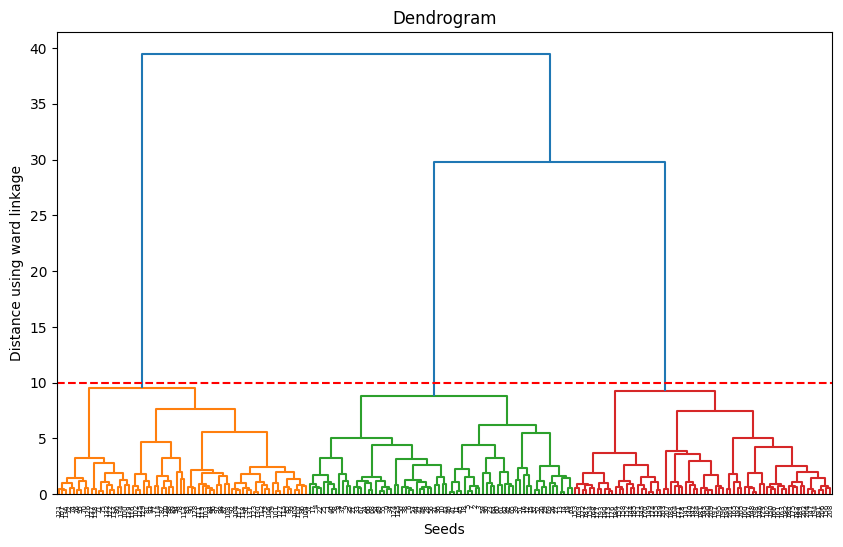

In [103]:
plt.figure(figsize=(10, 6))
plt.title('Dendrogram')
d = sch.dendrogram(sch.linkage(scaled_X, method='ward'))
plt.axhline(y=10, color='r', linestyle='--') 
plt.xlabel('Seeds')
plt.ylabel('Distance using ward linkage')   
plt.show()

Code For Clustering 

In [104]:
cluster = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage='ward')
df['C_Labels'] = cluster.fit_predict(scaled_X)

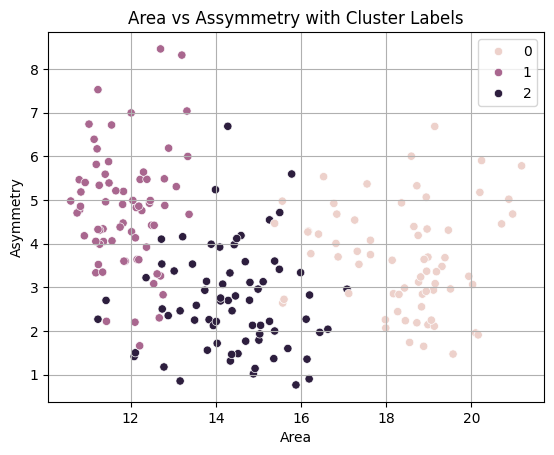

In [105]:
sns.scatterplot(data = df,x='Area', y='Assymetry', hue='C_Labels')
plt.title('Area vs Assymmetry with Cluster Labels')
plt.xlabel('Area')
plt.ylabel('Asymmetry')
plt.grid(True)
plt.legend()
plt.show()

In [106]:
score = silhouette_score(scaled_X, df['C_Labels']) 

In [107]:
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.484
